# Homework 3

## Juhi Malwade

## Normal and t distributions
## t-test


An experiment was conducted to determine the effect of children participating in a given meal preparation on calorie intake for that meal. Data are recorded below. 

Save the data to a format that can be read into python. Read the data in for analysis. Data is provided in two separted CSV files. 

* Use python to calculate the quantities and generate the visual summaries requested below. You will lose points if you are not utilizing python.

* You can use scipy libary or other libraries to do your tests or you can implement them from scratch in python 



In [107]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

In [108]:
df = pd.read_csv("participants.csv")
non_df = pd.read_csv("nonparticipants.csv")

# Question - 1
Summarize the data by whether children participated in the meal preparation or not. Use an appropriately labelled table to show the results. Also include a graphical presentation that shows the distribution of calories for participants vs. non-participants. Describe the shape of each distribution and comment on the similarity (or lack thereof) between the distributions in each population. **(2 points)**

Be aware that there is not one specific way the graph needs to look. Experiment with different types of graphs, and different parameters for the graph type. Your goal is to present the data as readable as possible. 

In [109]:
non_df.columns = ['calories']
df.columns = ['calories']

# Add group labels
non_df['meal_group'] = 'not participants'
df['meal_group'] = 'participants'

combined_df = pd.concat([df, non_df], ignore_index=True)

In [110]:
combined_df.groupby('meal_group')['calories'].agg([("count","count"), ("mean", "mean"), ("min", "min"), ("median", "median"),
                                              ("max", "max")])

,count,mean,min,median,max
meal_group,,,,,
not participants,22,374.071818,139.69,374.74,688.77
participants,25,410.079600,210.99,424.94,635.21


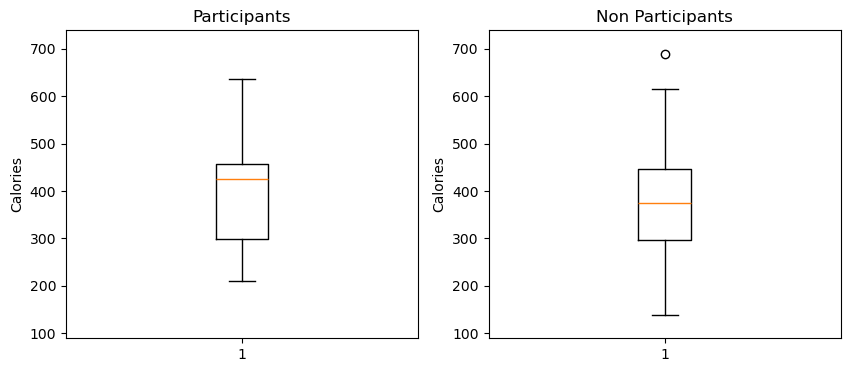

In [111]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.boxplot(df['calories'], label = "participants")
ax1.set_title('Participants')
ax1.set_ylabel('Calories')

ax2.boxplot(non_df['calories'], label = "participants")
ax2.set_title('Non Participants')
ax2.set_ylabel('Calories')

y_min = min(df['calories'].min(), non_df['calories'].min())
y_max = max(df['calories'].max(), non_df['calories'].max())

ax1.set_ylim([y_min - 50, y_max + 50])
ax2.set_ylim([y_min - 50, y_max + 50])

plt.show()

The graph shows two boxplots, where one represents the calorie distribution of participants of the meal preperation, and the second represents the calorie distribution of non-participants in the meal preperation. The participants had a higher median calorie intake than the non-participants. However, the participants also had a lower range, including a higher minimum and lower maximum calorie intake compared to non-participants. Therefore, based on the graph it is difficult to conclude if there is a significant difference in calorie intake between the two groups.

# Question - 2 

Does the mean calorie consumption for those who participated in the meal preparation differ from **425**? Formally test at the $\alpha = 0.05$ level using the 5 steps outlined in the module. **(6 points)**


### Step 1: Set up hypothesis and select alpha level.

Hypothesis: H0 : $ \mu $= 425, H1 : $ \mu $ $ \neq $ 425

$\alpha = 0.05$

### Step 2: Select the appropriate test statistic

Because the sample size is relatively small and we don't know the standard deviation of the population, we should use a one sample t-test.

### Step 3: State the decision rule

If $p \le \alpha$: reject $H_0$
 
If $p > \alpha$: fail to reject $H_0$

### Step 4: Compute the test statistic and associated p-value

In [112]:
t_stat, p_value = stats.ttest_1samp(df['calories'], popmean=425)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: -0.6139385690489593
p-value: 0.5450319510318798


### Step 5: State your conclusion

Because the p-value is less than $\alpha$, we fail to reject the null hypothesis. There is not siginficant evidence that mean calorie consumption for those who participated in the meal preparation differ from 425.

# Question -3 
Calculate a **90%** confidence interval for the mean calorie intake for participants in the meal preparation. Interpret the confidence interval. **(6 points)**

In [113]:
mean = df['calories'].mean()
margin_error = stats.t.ppf(0.95, len(df)-1) * df['calories'].sem()
print(mean - margin_error, mean + margin_error)

368.50044815647897 451.658751843521


Interpretation: We are 90% confident that the true mean calorie intake for participants in the meal preparation lies between 368.5 to 451.7 calories.

# Question 4 
Formally test whether or not participants consumed 
more calories than non-participants at the $\alpha = 0.05$ level using the 5 steps procedure for hypothesis tests. **(6 points )**

### Step 1: Set up hypothesis and select alpha level.

$\mu_P$ = mean calories for participants, 
$\mu_N$ = mean calories for non-participants

Hypothesis:

$H_0: \mu_P \le \mu_N$  
$H_a: \mu_P > \mu_N$

$\alpha = 0.05$

### Step 2: Select the appropriate test statistic

Because the sample sizes are small and we don't know the standard deviations of the population, we should use a two sample t-test.

### Step 3: State the decision rule

If $p \le \alpha$: reject $H_0$
 
If $p > \alpha$: fail to reject $H_0$

### Step 4: Compute the test statistic and p-value

In [114]:
t_stat, p_two_sided = stats.ttest_ind(
    df['calories'], non_df['calories'], equal_var=False
)

p_value = p_two_sided / 2

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 0.9636038701588588
p-value: 0.1703224943859592


### Step 5: State your conclusion

Because $p > \alpha$, we fail to reject $H_0$. There is not significant evidence that participants consumed more calories than non-participants.